# Monitoring API latency with Spark MLlib

**Data Stream · practical · Student notebook**

We monitor several APIs. Every five seconds, each API reports the latencies
(in milliseconds) and statuses of the requests it handled. We first turn these
raw reports into features, then flag unusual behaviour with clustering, and
finally predict the latency of the next minute with regression.

```text
raw reports → features → K-Means → anomaly flags
                    ↓
              next-minute target → linear regression / random forest
```

**How to work:** run the **Given** cells unchanged. Complete the **TODO** edits
and questions in order. Starter cells are valid Python, but some use provisional
values or incomplete analyses; running them is not the same as solving them.

Budget: setup 5 min · exploration 11 min · clustering 31 min ·
regression 35 min · buffer 8 min.


## Part I — Loading and exploring the data (16 min including setup)

**Given — Spark session.** You should already have run
`python check_environment.py` in your activated Miniforge environment and seen
**Environment ready.** We use the same environment as the previous lab.

The helper below selects this environment's Java/Python without requiring shell
variables. Spark runs locally with two worker threads.


In [1]:
from pathlib import Path
import sys

# Works when opened from the lab directory or one of its subdirectories.
ROOT = Path.cwd().resolve()
if not (ROOT / "environment.yml").exists():
    ROOT = ROOT.parent
assert (ROOT / "environment.yml").exists(), "Launch Jupyter from the lab directory."
sys.path.insert(0, str(ROOT))
from lab_support import configure_local_environment
configure_local_environment()

from pyspark.sql import SparkSession, functions as F
spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("api-latency-lab")
    .config("spark.driver.memory", "768m")
    .config("spark.sql.shuffle.partitions", "2")
    .config("spark.default.parallelism", "2")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
OUTPUT = ROOT / "artifacts"
print("Python:", sys.executable)
print("Spark:", spark.version, "| master:", spark.sparkContext.master)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/05 18:26:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Python: /Users/antoinechosson/miniforge3/envs/data-stream-spark/bin/python
Spark: 4.0.4 | master: local[2]


**Given — the dataset.** `api_latency_data.parquet` contains one row per API
every five seconds, over seven days:

- `timestamp`: Unix timestamp (seconds since epoch, UTC)
- `api_id`: API identifier, `API_1` to `API_5`
- `latency_list`: latencies in milliseconds of the requests handled during
  the interval, stored as a string such as `"[120.5, 130.2]"`
- `request_status_list`: the matching request statuses, `"success"` or
  `"failure"`, also stored as a string

The lists are strings, so we first parse them into arrays.


In [2]:
DATA = ROOT / "data/api_latency_data.parquet"
assert DATA.exists(), "Download api_latency_data.parquet into data/ (see README.md)."
df = spark.read.parquet(DATA.as_uri())
df.printSchema()
df.show(3, truncate=80)

df_parsed = (
    df.withColumn(
        "latency_array",
        F.split(F.regexp_replace("latency_list", r"[\[\]]", ""), r",\s*").cast("array<double>"),
    )
    .withColumn(
        "status_array",
        F.split(F.regexp_replace("request_status_list", r"[\[\]'\"]", ""), r",\s*"),
    )
)


root
 |-- timestamp: long (nullable = true)
 |-- api_id: string (nullable = true)
 |-- latency_list: string (nullable = true)
 |-- request_status_list: string (nullable = true)

+----------+------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
| timestamp|api_id|                                                                    latency_list|                                                             request_status_list|
+----------+------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|1704063600| API_1|[30.366269583247124, 12.315896620957101, 86.19303970141357, 33.89362898289543...|["success", "success", "success", "success", "success", "success", "success",...|
|1704063600| API_2|[31.87715947707908, 28.421809460703756, 18.71289393321499, 25.0704896054043

### Task 1.1 — Explore the data (8 min)

**TODO:** count the records, then compute summary statistics of the average
latency of each report, grouped by `api_id`: mean, standard deviation, min,
max, median and number of records. The average of an array column can be
computed with `F.aggregate` and `F.size`. Useful patterns:
`df.groupBy("col").agg(F.mean("x").alias("..."), ...)`,
`F.percentile_approx("x", 0.5)`.


In [22]:
df_with_avg = df_parsed.withColumn(
    "avg_latency_ms",
    F.aggregate("latency_array", F.lit(0.0), lambda acc, x: acc + x) / F.size("latency_array"),
)

# TODO: add the remaining statistics.
(df_with_avg.groupBy("api_id")
    .agg(F.mean("avg_latency_ms").alias("mean_latency"),
        F.std("avg_latency_ms").alias("std_latency"),
        F.min("avg_latency_ms").alias("min_latency"),
        F.max("avg_latency_ms").alias("max_latency"),
        F.median("avg_latency_ms").alias("median_latency"),
        F.count("avg_latency_ms").alias("number_records"))
    .orderBy("api_id")
    .show())

print("Total records:", df_with_avg.count())


+------+------------------+------------------+------------------+------------------+------------------+--------------+
|api_id|      mean_latency|       std_latency|       min_latency|       max_latency|    median_latency|number_records|
+------+------------------+------------------+------------------+------------------+------------------+--------------+
| API_1|105.05390231722002| 58.32720118184045|25.457893507543414|1117.8873832827721|   96.393243821154|        120960|
| API_2|246.04397889147086| 880.9739875116078|31.303873923236303|           10000.0|157.15331593712207|        120960|
| API_3|230.43271209493545| 931.3467551322404|35.585850039431016|           10000.0|133.98399309039547|        120960|
| API_4| 173.3430049179274| 656.6237048008377|29.082446624483858|           10000.0|121.40214809685791|        120960|
| API_5| 95.14606327227719|39.784881004125616|  51.2266940915288| 635.1548001310783| 98.60674646223674|        120960|
+------+------------------+------------------+--

### Task 1.2 — Time-series features (3 min)

**Given.** We derive the following features for each report:

- `hour_of_day` (0–23) and `day_of_week` (0–6, where 0 is Monday)
- `is_weekend` and `is_business_hours` (9:00–17:00 on weekdays)
- `request_count`, `error_rate` and `avg_latency_ms`

Parsing the raw strings is the expensive step, and K-Means passes over the
data many times. We therefore **cache** the small numeric result in memory:
the first action computes it once, later ones reuse it.


In [4]:
df_features = (
    df_parsed
    .withColumn("ts", F.timestamp_seconds("timestamp"))
    .withColumn("hour_of_day", F.hour("ts"))
    # Spark's dayofweek is 1 = Sunday … 7 = Saturday; shift to 0 = Monday.
    .withColumn("day_of_week", (F.dayofweek("ts") + 5) % 7)
    .withColumn("is_weekend", F.col("day_of_week") >= 5)
    .withColumn(
        "is_business_hours",
        (F.col("day_of_week") < 5) & F.col("hour_of_day").between(9, 16),
    )
    .withColumn("request_count", F.size("latency_array"))
    .withColumn(
        "error_rate",
        (F.size(F.filter("status_array", lambda s: s == "failure"))
         / F.size("status_array")).cast("float"),
    )
    .withColumn(
        "avg_latency_ms",
        (F.aggregate("latency_array", F.lit(0.0), lambda acc, x: acc + x)
         / F.size("latency_array")).cast("float"),
    )
    .drop("ts", "latency_list", "request_status_list", "latency_array", "status_array")
    .cache()
)
print("Cached rows:", df_features.count())
df_features.printSchema()
df_features.show(5)


Cached rows: 604800
root
 |-- timestamp: long (nullable = true)
 |-- api_id: string (nullable = true)
 |-- hour_of_day: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: boolean (nullable = true)
 |-- is_business_hours: boolean (nullable = true)
 |-- request_count: integer (nullable = true)
 |-- error_rate: float (nullable = true)
 |-- avg_latency_ms: float (nullable = true)

+----------+------+-----------+-----------+----------+-----------------+-------------+-----------+--------------+
| timestamp|api_id|hour_of_day|day_of_week|is_weekend|is_business_hours|request_count| error_rate|avg_latency_ms|
+----------+------+-----------+-----------+----------+-----------------+-------------+-----------+--------------+
|1704063600| API_1|         23|          6|      true|            false|           43|0.023255814|     60.742386|
|1704063600| API_2|         23|          6|      true|            false|           35|        0.0|       98.0928|
|1704063600| A

## Part II — Anomaly detection with clustering (31 min)

### Task 2.1 — Feature vectors and standardisation (4 min)

**Given.** MLlib estimators read a single vector column. `VectorAssembler`
combines `avg_latency_ms`, `request_count`, `error_rate` and `hour_of_day`
into one vector; `StandardScaler` then gives every feature zero mean and unit
variance.


In [5]:
from pyspark.ml.feature import StandardScaler, VectorAssembler

feature_cols = ["avg_latency_ms", "request_count", "error_rate", "hour_of_day"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
df_assembled = assembler.transform(df_features)

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

df_scaled.select("timestamp", "api_id", "features_raw", "features").show(5, truncate=False)
print("Feature means:", scaler_model.mean)
print("Feature std devs:", scaler_model.std)


+----------+------+--------------------------------------------------+---------------------------------------------------------------------------------+
|timestamp |api_id|features_raw                                      |features                                                                         |
+----------+------+--------------------------------------------------+---------------------------------------------------------------------------------+
|1704063600|API_1 |[60.74238586425781,43.0,0.023255813866853714,23.0]|[-0.1686378010374489,-0.6143590350460282,-0.18732849379845765,1.6613233991333418]|
|1704063600|API_2 |[98.0927963256836,35.0,0.0,23.0]                  |[-0.11098997073203778,-0.9270645746844025,-0.8444156013809485,1.6613233991333418]|
|1704063600|API_3 |[105.98393249511719,42.0,0.0476190485060215,23.0] |[-0.09881053620394306,-0.653447227500825,0.5010485061233318,1.6613233991333418]  |
|1704063600|API_4 |[68.09210205078125,35.0,0.05714285746216774,23.0] |[-0.15729401

**TODO — question:** why does K-Means need standardised features?

* Standardized features are all on the same scale such that they contribute comparably to the distances.
* K-Means works with distances (to assign nearest cluster or minimise within cluster sum of square distance), large numeric features would greatly modify the result regardless of its importance. Some features might have a greater scale than others (because of its intrinsic purpose or its unit) and therefore weight much more in the computation.
* Normalization helps the process reflect the structure of the data, unbiased by the scales or choices of units. 


### Task 2.2 — K-Means clustering (15 min)

**TODO:**
- train a K-Means model with `k=4` on the `features` column (use `seed=42`);
- assign a cluster label to each row;
- compute the mean of each feature per cluster;
- identify the anomalous cluster and add a boolean `is_anomaly` column.

Useful patterns: `KMeans(k=..., featuresCol=..., predictionCol="cluster", seed=42)`,
`model = estimator.fit(df)`, `model.transform(df)`.


In [6]:
from pyspark.ml.clustering import KMeans

# TODO: train K-Means and assign clusters.
df_clustered = df_scaled.withColumn("cluster", F.lit(0))
estimator = KMeans(k=4, featuresCol="features", predictionCol="cluster", seed=42)
model = estimator.fit(df_scaled)
df_clustered = model.transform(df_scaled) 

In [7]:
# TODO: compute the mean of each feature per cluster.
cluster_stats = df_clustered.groupBy("cluster").count()
cluster_stats.orderBy("cluster").show()
df_clustered.groupby("cluster").mean(*feature_cols).show()


+-------+------+
|cluster| count|
+-------+------+
|      0|189010|
|      1|204066|
|      2|209137|
|      3|  2587|
+-------+------+

+-------+-------------------+------------------+--------------------+------------------+
|cluster|avg(avg_latency_ms)|avg(request_count)|     avg(error_rate)|  avg(hour_of_day)|
+-------+-------------------+------------------+--------------------+------------------+
|      2| 181.62436397545213| 88.22585673505884|0.036342861801138104|11.954321808192717|
|      0| 118.60425834394398| 50.52954870112693|0.026620580763070962|19.585323527855667|
|      1|    81.084613698964|36.765325923965776| 0.02291123334932837| 3.595008477649388|
|      3|            10000.0|               3.0| 0.29661126959540457|7.6026285272516425|
+-------+-------------------+------------------+--------------------+------------------+



Cluster 3 is the anomalous one, it is the smallest in size and has means of error_rate, request_count and avg_latency_ms very far (absolute difference) from the other clusters. Its per-feature means sit far from those of the other three clusters. The other three clusters have similar profiles and represent normal traffic patterns.


In [8]:
# TODO: choose the anomalous cluster from cluster_stats.
anomaly_cluster_id = 3
df_clustered = df_clustered.withColumn("is_anomaly", F.col("cluster") == anomaly_cluster_id)

### Task 2.3 — Elbow method (8 min)

**TODO:** train K-Means for `k` from 2 to 6 and record the within-set sum of
squared errors (WSSSE) of each model, available as `model.summary.trainingCost`.
Then look at the plot: which `k` would you choose?


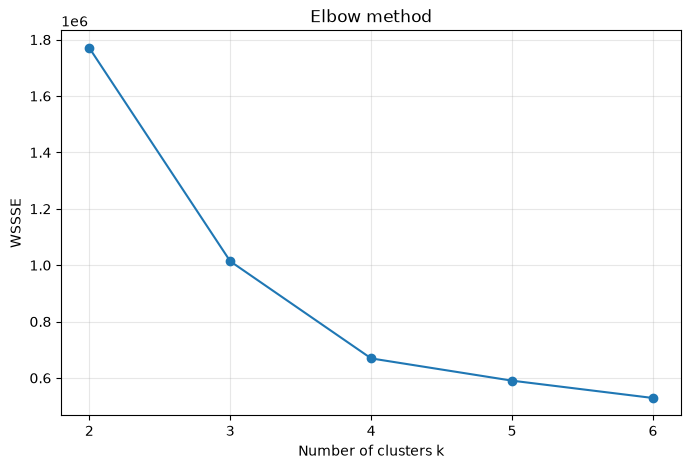

In [9]:
import matplotlib.pyplot as plt

k_values = list(range(2, 7))
# TODO: replace the placeholder values with each model's WSSSE.
wssse_values = []
for k in k_values: 
    estimator = KMeans(k=k, featuresCol="features", predictionCol="cluster", seed=42)
    model = estimator.fit(df_scaled)
    wssse = model.summary.trainingCost
    wssse_values.append(wssse)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wssse_values, "o-")
plt.xlabel("Number of clusters k")
plt.ylabel("WSSSE")
plt.title("Elbow method")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()


**TODO — observation:** which `k` would you choose, and what characterises the
anomalous cluster of Task 2.2?

Using the elbow method, k = 4 is the best number of clusters to detect anomalous requests. 

Anomalous reports are characterised by very small number of requests but with a high latency and error rate (10x the normal metrics as seen on healthy clusters) 

### Task 2.4 — Deliverable (4 min)

**TODO:** write `artifacts/elbow_anomaly_clustering.parquet` with three columns:
`timestamp`, `api_id` and `is_anomaly`.


In [10]:
# TODO: select the three required columns.
df_anomaly_output = df_clustered.select("timestamp", "api_id", "is_anomaly")
df_anomaly_output.write.mode("overwrite").parquet((OUTPUT / "elbow_anomaly_clustering.parquet").as_uri())

## Part III — Latency prediction with regression (35 min)

### Task 3.1 — Prepare the training data (8 min)

**TODO:** keep only `API_5`, then add a column `latency_next_minute`: the mean
of `avg_latency_ms` over the next 60 seconds. Reports arrive every five
seconds, so the window `w_future` below covers the next 12 rows.
Useful pattern: `F.avg("col").over(window)`.


In [11]:
from pyspark.sql import Window

w_future = Window.partitionBy("api_id").orderBy("timestamp").rowsBetween(1, 12)

# TODO: keep only API_5, and replace the provisional target (the current latency).
df_api5 = (df_features
    .filter(F.col('api_id')=='API_5')
    .withColumn("latency_next_minute", F.avg("avg_latency_ms").over(w_future).cast("double")))


# The last rows have no future window.
df_api5 = df_api5.filter(F.col("latency_next_minute").isNotNull()).cache()
print("Records after creating the target:", df_api5.count())


Records after creating the target: 120959


### Task 3.2 — Split by time (3 min)

**Given.** We train on the earliest 80% of the time range and test on the
latest 20%. A random split would leak future information into training.


In [12]:
ts_min, ts_max = df_api5.agg(F.min("timestamp"), F.max("timestamp")).first()
ts_cutoff = ts_min + int(0.8 * (ts_max - ts_min))
df_train = df_api5.filter(F.col("timestamp") <= ts_cutoff)
df_test = df_api5.filter(F.col("timestamp") > ts_cutoff)
print("Train size:", df_train.count())
print("Test size:", df_test.count())

reg_features = ["avg_latency_ms", "request_count", "error_rate", "hour_of_day"]
reg_assembler = VectorAssembler(inputCols=reg_features, outputCol="reg_features")
df_train_vec = reg_assembler.transform(df_train)
df_test_vec = reg_assembler.transform(df_test)


Train size: 96767
Test size: 24192


### Task 3.3 — Linear regression (10 min)

**TODO:** train a `LinearRegression` on `reg_features` to predict
`latency_next_minute`, with prediction column `predicted_latency_lr`. Predict
on the test set and report RMSE and R² with `RegressionEvaluator`.


In [14]:
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import LinearRegression

# TODO: train the model and predict on the test set.
df_test_lr = df_test_vec.withColumn("predicted_latency_lr", F.lit(0.0))
LR = LinearRegression(featuresCol='reg_features', 
                         labelCol='latency_next_minute',
                         predictionCol='predicted_latency_lr')
model = LR.fit(df_train_vec)
df_test_lr = model.transform(df_test_vec)

evaluator = RegressionEvaluator(labelCol="latency_next_minute", predictionCol="predicted_latency_lr")
lr_rmse = evaluator.evaluate(df_test_lr, {evaluator.metricName: "rmse"})
# TODO: compute R² as well.
lr_r2 = evaluator.evaluate(df_test_lr, {evaluator.metricName: "r2"})
print(f"Linear regression: RMSE {lr_rmse:.4f}, R² {lr_r2}")


Linear regression: RMSE 2.3009, R² 0.9955600512295438


### Task 3.4 — Random forest (10 min)

**TODO:** train a `RandomForestRegressor` on the same features, with prediction
column `predicted_latency_rf` (use `seed=42`). Apply it to `df_test_lr`, so both
predictions end up in one DataFrame. Compare its RMSE and R² with the linear
model, and print the feature importances (`model.featureImportances`).


In [18]:
from pyspark.ml.regression import RandomForestRegressor

# TODO: train the model and predict on df_test_lr.
df_test_rf = df_test_vec.withColumn("predicted_latency_rf", F.lit(0.0))

RF = RandomForestRegressor(featuresCol='reg_features',
                           labelCol='latency_next_minute',
                           predictionCol='predicted_latency_rf',
                           seed=42)

rf_model = RF.fit(df_train_vec)
df_test_rf = rf_model.transform(df_test_lr) 

# TODO: evaluate, compare with linear regression, and print feature importances.
evaluator = RegressionEvaluator(labelCol="latency_next_minute", predictionCol="predicted_latency_rf")
rf_rmse = evaluator.evaluate(df_test_rf, {evaluator.metricName: "rmse"})
rf_r2 = evaluator.evaluate(df_test_rf, {evaluator.metricName: "r2"})

print(f"Random Forest Regression: RMSE {rf_rmse:.4f}, R² {rf_r2:.4f}")
print("Feature Importance") 
print(rf_model.featureImportances)


Random Forest Regression: RMSE 2.4090, R² 0.9951
Feature Importance
(4,[0,1,2,3],[0.45598476214414935,0.334481618011521,0.005756331792624934,0.20377728805170475])


**TODO — observation:** which model is better? Which feature matters most?

The Linear Regression model performs better with a lower RMSE of 2.3009 vs 2.4090 for Random Forest. This indicates that the relationship between the current latency and traffic volume and the next minute's latency is simple (likely proprotional) and therefore regression is sufficient for this task. The R2 coef is very high (99.5%+) in both models which indicates that the current state is very correlated with the next minutes' one.

The feature importance is distributed as follows:
* avg_latency_ms: 45.6%
* request_count: 33.4%
* error_rate: 0.57%
* hour_of_day: 20.4%

As expected, the current latency matters the most when predicting the next minute's latency; followed by the current number of requests. The current error rate matters very little in this prediction. 





### Task 3.5 — Deliverable (4 min)

**TODO:** write `artifacts/latency_predictions.parquet` for the test set, with
columns `timestamp`, `api_id`, `actual_latency` (the target),
`predicted_latency_lr` and `predicted_latency_rf`.


In [20]:
# TODO: select and rename the required columns.
df_predictions = df_test_rf.select("timestamp", 
                                   "api_id", 
                                   F.col("latency_next_minute").alias("actual_latency"), 
                                   "predicted_latency_lr", 
                                   "predicted_latency_rf")
df_predictions.write.mode("overwrite").parquet((OUTPUT / "latency_predictions.parquet").as_uri())


## Deliverables

Submit this notebook with all tasks completed, together with the two folders
written to `artifacts/`: `elbow_anomaly_clustering.parquet` (Part II) and
`latency_predictions.parquet` (Part III).

**Given — cleanup.** Run the cell below to release the cache and stop Spark. To
begin again, restart the kernel and run from the top.


In [23]:
spark.catalog.clearCache()
spark.stop()
print("Spark stopped.")


Spark stopped.
